In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pickle
import arviz_plots as azp
import arviz as az

In [10]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox', 'scaled_no2', 'scaled_formaldehyd', 'scaled_acetone',
       'scaled_acetald', 'scaled_bc', 'scaled_PM25', 'no2_street', 'nox_street',
       'pm25_street', 'bmi_6_yrs', 'gestational_age', 'mother\'s_education_1yr',
       'lrti_1y', 'genetic_risk_score_asthma', 'PCA1', 'PCA2']],df.verificeret_18y

In [11]:
def rescale_splits(idata, folds, X_ref, chains_per_fold=4, per_sd=True):
    W, B = idata["posterior"]["weight"], idata["posterior"]["bias"]
    fdim = W.dims[-1]

    mu_ref = xr.DataArray(np.nanmean(X_ref.values, axis=0), dims=[fdim])
    sd_ref = xr.DataArray(np.nanstd(X_ref.values,  axis=0), dims=[fdim])

    W_out, B_out = xr.full_like(W, np.nan), xr.full_like(B, np.nan)
    for i in range(len(folds["mean_scale"])):
        sl = slice(i * chains_per_fold, (i + 1) * chains_per_fold)
        mu = xr.DataArray(np.asarray(folds["mean_scale"][i]), dims=[fdim])
        sd = xr.DataArray(np.asarray(folds["std_scale"][i]),  dims=[fdim])

        w_nat = W.isel(chain=sl) / sd                              # natural units
        b_nat = B.isel(chain=sl) - ((W.isel(chain=sl) * mu) / sd).sum(dim=fdim)

        if per_sd:
            W_out[dict(chain=sl)] = (w_nat * sd_ref).values
            B_out[dict(chain=sl)] = (b_nat + (w_nat * mu_ref).sum(dim=fdim)).values
        else:
            W_out[dict(chain=sl)] = w_nat.values
            B_out[dict(chain=sl)] = b_nat.values

    assert not np.isnan(W_out).any()
    return np.exp(W_out), B_out

In [12]:


paths = [f"../Models/asthma_7_year_adjusted_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_7 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_adjusted_7y.pkl", "rb") as f:
    data_7_ad = pickle.load(f)  
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","BMI","Gestational age","Mother education","PRS","LRTI","PC 1","PC 2"]
combined_posterior_7 = combined_posterior_7.assign_coords(weight_dim_0=list_parameters)
asthma_7 = xr.DataTree.from_dict({"posterior": combined_posterior_7})
asthma_7["posterior"]["weight_OR"],asthma_7["posterior"]["rescaled_bias"]=rescale_splits(asthma_7,data_7_ad,X)


In [13]:


paths = [f"../Models/asthma_12_year_adjusted_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_12 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_adjusted_12y.pkl", "rb") as f:
    data_12_ad = pickle.load(f)  

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","BMI","Gestational age","Mother education",'LRTI',"PRS","PC 1","PC 2"]
combined_posterior_12 = combined_posterior_12.assign_coords(weight_dim_0=list_parameters)
asthma_12 = xr.DataTree.from_dict({"posterior": combined_posterior_12})
asthma_12["posterior"]["weight_OR"],asthma_12["posterior"]["rescaled_bias"]=rescale_splits(asthma_12,data_12_ad,X)


In [14]:


paths = [f"../Models/asthma_18_year_adjusted_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_18 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_adjusted_18y.pkl", "rb") as f:
    data_18_ad = pickle.load(f)  

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","BMI","Gestational age","Mother education",'LRTI',"PRS","PC 1","PC 2"]
combined_posterior_18 = combined_posterior_18.assign_coords(weight_dim_0=list_parameters)

asthma_18 = xr.DataTree.from_dict({"posterior": combined_posterior_18})
asthma_18["posterior"]["weight_OR"],asthma_18["posterior"]["rescaled_bias"]=rescale_splits(asthma_18,data_18_ad,X)


/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


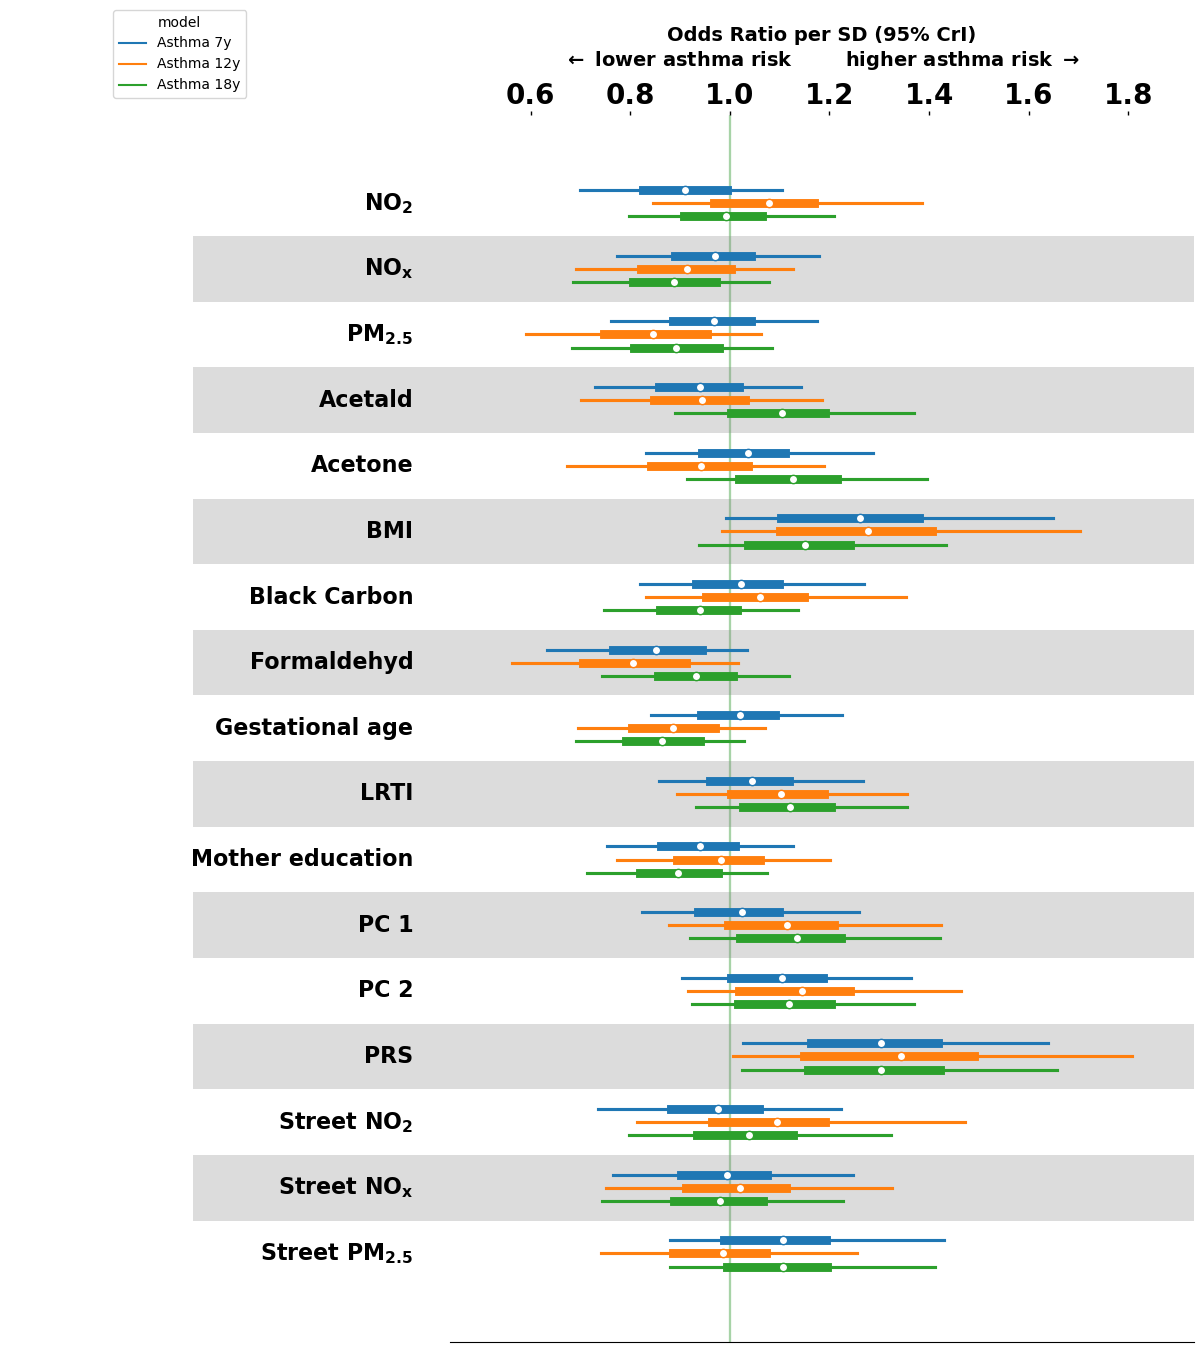

In [15]:

rope = [(0.999, 1.001)]
plt.rcParams["mathtext.default"] = "bf"
plt.rcParams["mathtext.fontset"] = "dejavusans"   # or "custom" + mathtext.bf
pc = azp.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR", shade_label="weight_dim_0",                # native alternate shading
     visuals={"shade": {"color": "0.55"},
             "labels": {"size": 16, "weight": "bold"}}     # gray; alpha 0/0.3 alternates
)
pc.add_legend("model", loc="upper left", bbox_to_anchor=(0.05, 0.95))
forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

pc.coords = {"column": "forest"}
pc = azp.add_bands(
    pc,
    values=rope,
    visuals={"ref_band":{"color": "green"}},
)
for spine in ("top", "right", "left"):
    forest_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", labelsize=100, length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=20, pad=0)
forest_ax.set_ylabel("",fontweight="bold",fontsize=40)
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
for ax in fig.axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)
for line in forest_ax.lines:
    c = line.get_color()
    if c not in ("black", "k", "#000000", (0.0, 0.0, 0.0, 1.0)):
        line.set_linewidth(line.get_linewidth() * 3.2)

labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=60, length=0, pad=0)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")
for tl in forest_ax.get_yticklabels():
    tl.set_fontweight("bold")            
for txt in list(fig.texts):
    if "weight" in txt.get_text().lower():
        txt.set_vis
fig.canvas.draw()   # make sure tick labels exist before styling them

for tl in labels_ax.get_yticklabels():
    tl.set_fontweight("bold")

# arviz-plots sometimes draws row labels as Text artists rather than ticks
for txt in labels_ax.texts:
    txt.set_fontweight("bold")
fig.set_layout_engine("none")   # arviz-plots may use constrained layout

extra = 0.15               # figure fraction to steal
lb, fb = labels_ax.get_position(), forest_ax.get_position()
labels_ax.set_position([lb.x0 - extra, lb.y0, lb.width + extra, lb.height])
forest_ax.set_position([fb.x0, fb.y0, fb.width, fb.height])   # unchanged
fig.savefig("../Plots/arviz_adjusted.png", bbox_inches="tight", dpi=300)